# Programming Assignment 1 — Segmentação de instâncias com as arquiteturas da aula

| | |
|---|---|
| **Disciplina** | Aprendizado Profundo (Deep Learning) |
| **Professor** | Dario Oliveira |
| **Monitor** | Erick Brito |
| **Entrega** | 10/09, 23h59 — B41254@fgv.edu.br |
| **Apresentação** | Em sala, data a definir |
| **Formato** | Duplas |

**Dupla:** `Bryan Monteiro`, `Sofia Azeredo`

---

> Este notebook é o **template de trabalho**. Cada seção do enunciado tem um espaço dedicado:
> células markdown com o enunciado original + células de código para preencher + células markdown
> `**Resposta:**` para a discussão que a apresentação vai exigir.
>
> Lembrar que os entregáveis obrigatórios são separados: `README.md`, `AI_LOG.md`,
> `inferencia.ipynb` (roda sem retreinar) e o checkpoint. Este notebook é o caderno de experimentos.

## 1. O problema

Essa entrega é pensada considerando o que viram na aula de Segmentação Semântica.

O quarto slide da aula fez a distinção: segmentação semântica produz rótulos **class-aware**; segmentação
de instâncias produz rótulos **instance-aware**. Os oitenta slides seguintes trataram exclusivamente do
primeiro caso — FCN, SegNet, U-Net, ResUNet, DeepLab, PSPNet.

Este PA é a outra metade. A tarefa é fazer **as mesmas arquiteturas vistas em aula** produzirem rótulos
instance-aware, **sem usar detectores com proposta de região** (Mask R-CNN e afins estão proibidos).

Isso é possível, e é assim que boa parte da literatura de segmentação de células e de edificações funciona,
mas exige projetar três coisas que a aula não entregou prontas:

1. **o que a rede prevê** (a representação de saída);
2. **qual perda otimiza isso** (a aula deu algumas: CE, CE balanceada, focal, L1/L2);
3. **como decodificar a previsão em objetos** (pós-processamento).

Essas três decisões são acopladas e dependem do dataset. É aí que está o trabalho.

### Decisões de projeto (preencher antes de começar)

**Representação de saída escolhida:**

**Perda(s):**

**Decodificação / pós-processamento:**

**Por que essas três se acoplam neste dataset:**

## 2. Dados

**Opção A (padrão) — DSB2018 / BBBC038v1.** Microscopia com máscara individual por núcleo
(cerca de 670 imagens de treino, cada núcleo em um PNG separado, sem sobreposição). Núcleos encostados
são a regra, não a exceção.

- Download direto, sem conta: https://bbbc.broadinstitute.org/BBBC038
- Ou `kaggle competitions download -c data-science-bowl-2018` (usar `stage1_train`)

**Opção B — edificações em imagem aérea (AICrowd / CrowdAI Mapping Challenge).** Tiles RGB de
300 × 300 com anotações de footprints em formato COCO. Mais próximo das imagens usadas na aula, e com
o desafio extra de prédios geminados. Exige conta na plataforma para baixar.

Em qualquer caso: **split treino/validação/teste estratificado por modalidade ou cidade**, justificado na
apresentação.

**Opção escolhida e justificativa do split:**

## 3. Regras de engenharia

**Permitido:** PyTorch, encoders pré-treinados em ImageNet (VGG/ResNet/Xception/MobileNet),
`albumentations`, `scipy.ndimage`, `skimage.segmentation`, `sklearn.cluster`.

**Proibido:**

- `torchvision.models.detection`, `detectron2`, `mmdetection`, `ultralytics`, SAM, Cellpose, StarDist,
  ou qualquer modelo pronto de segmentação de instâncias;
- métricas de AP de instância prontas de biblioteca — **vocês implementam o matching**;
- clonar uma solução pronta do DSB2018. Se usarem ideia de repo ou paper, **citem e reescrevam**.

O decoder, as perdas e o pós-processamento são de autoria de vocês.

### Setup — imports, seeds, device

In [ ]:
# Imports globais, seeds, device, paths.
import os, random, json, math, time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 42


def set_seed(seed: int) -> None:
    """Fixa as seeds de random, numpy e torch (inclusive CUDA) para reprodutibilidade."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = Path("dados")          #
CKPT_DIR = Path("checkpoints")
FIG_DIR = Path("figuras")
CKPT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print(f"device={DEVICE} | torch={torch.__version__} | amostras em {DATA_DIR}: "
      f"{len(list(DATA_DIR.iterdir())) if DATA_DIR.exists() else 0}")

device=cuda | torch=2.9.1+cu128 | amostras em dados: 670


---

# Parte 0 — Teste unitário sintético

Antes de tocar em dados reais, gerem um dataset sintético próprio: imagens **128 × 128** com **5 a 20
elipses** de tamanhos variados, muitas delas se tocando, com **ruído e contraste variáveis**. Vocês têm as
máscaras de instância de graça.

É o teste unitário de vocês: **mostrem que treina em menos de 5 minutos e reportem a métrica.**

### 0.1 Gerador sintético de elipses

In [6]:
from scipy import ndimage

def _rasterize_ellipse(yy, xx, cy, cx, a, b, theta):
    """Máscara booleana da elipse de centro (cy, cx), semieixos (a, b) e rotação theta."""
    ct, st = np.cos(theta), np.sin(theta)
    dy, dx = yy - cy, xx - cx
    u = (dx * ct + dy * st) / a
    v = (-dx * st + dy * ct) / b
    return (u * u + v * v) <= 1.0


def make_synthetic_sample(
    rng,
    size=128,
    n_min=5,
    n_max=20,
    axis_range=(5.0, 16.0),
    touch_prob=0.75,
    min_area_frac=0.45,
    min_area_px=25,
):
    """Retorna (image float32 HxW, labels int32 HxW) com 0 = fundo.

    As elipses não se sobrepõem (como no DSB2018): o pixel disputado fica com a
    instância colocada primeiro, de modo que instâncias vizinhas ficam encostadas,
    compartilhando fronteira. Contraste, iluminação, borramento e ruído variam por imagem.
    """
    yy, xx = np.mgrid[0:size, 0:size].astype(np.float32)

    labels = np.zeros((size, size), np.int32)
    fg_level = np.zeros((size, size), np.float32)

    bg_level = float(rng.uniform(0.05, 0.35))
    contrast = float(rng.uniform(0.15, 0.75))

    n_target = int(rng.integers(n_min, n_max + 1))
    placed = []                   
    next_id = 1
    attempts = 0

    while len(placed) < n_target and attempts < 40 * n_target:
        attempts += 1
        a = float(rng.uniform(*axis_range))
        b = float(rng.uniform(*axis_range))
        theta = float(rng.uniform(0.0, np.pi))

        if placed and rng.random() < touch_prob:
            # Encosta a nova elipse em uma já colocada: distância entre centros menor
            # que a soma dos raios garante contato depois do recorte por oclusão.
            py, px, pa, pb, _ = placed[int(rng.integers(len(placed)))]
            ang = float(rng.uniform(0.0, 2.0 * np.pi))
            reach = (max(pa, pb) + max(a, b)) * float(rng.uniform(0.55, 0.95))
            cy, cx = py + reach * np.sin(ang), px + reach * np.cos(ang)
        else:
            cy = float(rng.uniform(0.0, size))
            cx = float(rng.uniform(0.0, size))

        mask = _rasterize_ellipse(yy, xx, cy, cx, a, b, theta)
        full = int(mask.sum())
        if full == 0:
            continue

        mask &= labels == 0                      # sem sobreposição
        area = int(mask.sum())
        if area < min_area_px or area < min_area_frac * full:
            continue                             # sobrou pouco: descarta a elipse

        labels[mask] = next_id
        fg_level[mask] = bg_level + contrast * float(rng.uniform(0.6, 1.4))
        placed.append((cy, cx, a, b, theta))
        next_id += 1

    # Fundo com iluminação não uniforme + objetos + borramento + ruído.
    tilt_y, tilt_x = rng.uniform(-0.08, 0.08, size=2)
    ramp = tilt_y * (yy / size - 0.5) + tilt_x * (xx / size - 0.5)
    img = bg_level + ramp
    fg = labels > 0
    img[fg] = fg_level[fg]

    img = ndimage.gaussian_filter(img, sigma=float(rng.uniform(0.6, 1.6)))
    img = img + rng.normal(0.0, float(rng.uniform(0.01, 0.10)), img.shape)

    return np.clip(img, 0.0, 1.0).astype(np.float32), labels


class SyntheticEllipses(torch.utils.data.Dataset):
    """Dataset sintético determinístico: a amostra i depende apenas de (seed, i).

    Devolve (imagem 1xHxW float32, labels HxW int64). Os alvos de cada parte
    (binário, fronteira, centro/offset, ...) são derivados de `labels` a jusante.
    """

    def __init__(self, n_samples=512, size=128, seed=0, **kwargs):
        self.n_samples = n_samples
        self.size = size
        self.seed = seed
        self.kwargs = kwargs

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        rng = np.random.default_rng([self.seed, idx])
        img, labels = make_synthetic_sample(rng, size=self.size, **self.kwargs)
        return torch.from_numpy(img)[None], torch.from_numpy(labels.astype(np.int64))

### 0.2 Visualização de amostras sintéticas

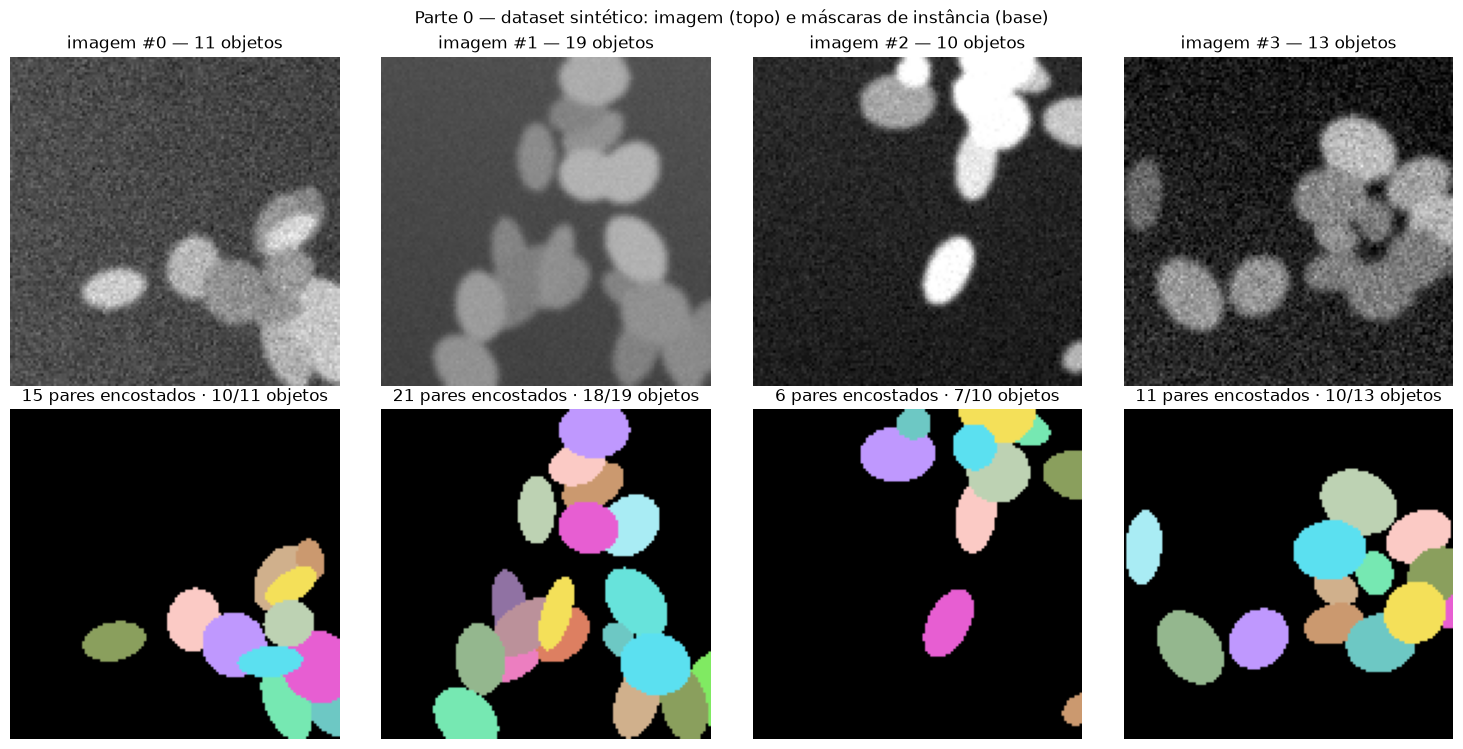

objetos por imagem: 13.2 (min 5, max 20)
objetos encostados em pelo menos um vizinho: 84.3%
área por objeto: min 25 px, max 723 px


In [7]:
# Grid com imagem + máscara de instâncias colorida, confirmando que há objetos se tocando.

def colorize_labels(labels, seed=0):
    """Mapa de labels -> RGB com uma cor aleatória por instância (fundo preto)."""
    rng = np.random.default_rng(seed)
    colors = rng.uniform(0.35, 1.0, size=(int(labels.max()) + 1, 3))
    colors[0] = 0.0
    return colors[labels]


def touching_pairs(labels):
    """Pares de instâncias que compartilham fronteira (vizinhança-8)."""
    pairs = set()

    def add(a, b):
        m = (a > 0) & (b > 0) & (a != b)
        for u, v in zip(a[m].ravel(), b[m].ravel()):
            pairs.add((min(u, v), max(u, v)))

    add(labels[1:, :], labels[:-1, :])
    add(labels[:, 1:], labels[:, :-1])
    add(labels[1:, 1:], labels[:-1, :-1])
    add(labels[1:, :-1], labels[:-1, 1:])
    return pairs


ds_demo = SyntheticEllipses(n_samples=8, size=128, seed=SEED)

fig, axes = plt.subplots(2, 4, figsize=(15, 7.6))
for k in range(4):
    img, labels = ds_demo[k]
    img, labels = img[0].numpy(), labels.numpy().astype(np.int32)
    pairs = touching_pairs(labels)
    n_obj = int(labels.max())
    n_touch = len({i for p in pairs for i in p})

    axes[0, k].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes[0, k].set_title(f"imagem #{k} — {n_obj} objetos")
    axes[1, k].imshow(colorize_labels(labels))
    axes[1, k].set_title(f"{len(pairs)} pares encostados · {n_touch}/{n_obj} objetos")
for ax in axes.ravel():
    ax.axis("off")
fig.suptitle("Parte 0 — dataset sintético: imagem (topo) e máscaras de instância (base)")
fig.tight_layout()
fig.savefig(FIG_DIR / "p0_amostras_sinteticas.png", dpi=120, bbox_inches="tight")
plt.show()

# Estatísticas agregadas: o enunciado pede "muitas delas se tocando".
ds_stats = SyntheticEllipses(n_samples=64, size=128, seed=SEED)
stats = []
for k in range(len(ds_stats)):
    labels = ds_stats[k][1].numpy().astype(np.int32)
    n_obj = int(labels.max())
    areas = np.bincount(labels.ravel())[1:]
    n_touch = len({i for p in touching_pairs(labels) for i in p})
    stats.append((n_obj, n_touch, areas.min(), areas.max()))
stats = np.array(stats)
print(f"objetos por imagem: {stats[:,0].mean():.1f} (min {stats[:,0].min()}, max {stats[:,0].max()})")
print(f"objetos encostados em pelo menos um vizinho: {100*stats[:,1].sum()/stats[:,0].sum():.1f}%")
print(f"área por objeto: min {stats[:,2].min()} px, max {stats[:,3].max()} px")

### 0.3 Treino rápido (< 5 min) no sintético

In [ ]:
# Loop de treino curto. Cronometrar e imprimir o tempo total.

### 0.4 Métrica no sintético

In [ ]:
# Reportar a métrica (mAP de instância e/ou IoU/Dice) no split sintético de validação.

**Resposta — Parte 0.** Tempo de treino, métrica obtida, e o que o teste unitário garante (ou não)
sobre o pipeline:

---

# Parte 1 — Baseline de segmentação semântica

1. Treinem **uma das arquiteturas da aula** para segmentação binária (fundo vs. objeto). Reportem
   **IoU** e **Dice**.
2. Extraiam instâncias pelo **método ingênuo**: limiar + componentes conexos.
3. Avaliem **como instâncias**. Atenção: o slide 6 define AP como precisão média sobre as classes — isso
   é a métrica semântica. Vocês precisam generalizar para o nível de instância: para cada limiar de IoU de
   **0,50 a 0,95 (passo 0,05)**, casar cada instância prevista com **no máximo uma** instância verdadeira,
   contar TP/FP/FN, calcular AP, e tirar a média (**mAP**). Reportem também o **erro absoluto de contagem
   por imagem**.
4. **Documentem a regra de matching** (guloso por IoU decrescente ou Hungarian). Regras diferentes dão
   números diferentes — a escolha é de vocês, mas tem que estar explícita.
5. **Quantifiquem o fracasso**: gráfico do mAP (ou do erro de contagem) em função da **densidade de
   objetos** na imagem. A tendência tem que ficar visível.

### 1.1 Dataset real — carregamento e split estratificado

In [ ]:
# Loader do dataset escolhido (Opção A ou B) + split treino/val/teste estratificado.

### 1.2 Arquitetura da aula (encoder-decoder) para segmentação binária

In [ ]:
# Modelo. Manter modular: o mesmo encoder-decoder será reaproveitado na Parte 2 trocando só a cabeça.

### 1.3 Treino do baseline

In [ ]:
# Loop de treino + validação, logging das curvas, salvamento do checkpoint.

### 1.4 Métricas semânticas — IoU e Dice

In [ ]:
def iou_score(pred_mask, gt_mask):
    ...

def dice_score(pred_mask, gt_mask):
    ...

# Reportar IoU e Dice no split de teste.

### 1.5 Extração ingênua de instâncias — limiar + componentes conexos

In [ ]:
# threshold -> scipy.ndimage.label / skimage.measure.label

### 1.6 Métrica de instância — mAP@[.50:.05:.95] implementada do zero

In [ ]:
# Matriz de IoU entre instâncias previstas e verdadeiras.
def instance_iou_matrix(pred_labels, gt_labels):
    ...

# Matching (guloso por IoU decrescente OU Hungarian) — escolher e documentar na célula abaixo.
def match_instances(iou_matrix, thresh):
    """Retorna (n_tp, n_fp, n_fn) com cada previsão casada a no máximo uma GT."""
    ...

def average_precision(pred_labels, gt_labels, thresh):
    ...

def mean_ap(pred_labels, gt_labels, thresholds=np.arange(0.50, 0.96, 0.05)):
    ...

def count_abs_error(pred_labels, gt_labels):
    ...

**Resposta — 1.4 Regra de matching.** Qual regra foi usada (gulosa por IoU decrescente ou Hungarian),
como empates são resolvidos, o que conta como FP e como FN, e por que essa escolha:

### 1.7 Avaliação do baseline como instâncias

In [ ]:
# Tabela: mAP, AP por limiar, erro absoluto de contagem médio.

### 1.8 Quantificação do fracasso — mAP vs. densidade de objetos

In [ ]:
# Definir densidade (nº de objetos por imagem e/ou fração de pixels em contato entre instâncias)
# e plotar mAP / erro de contagem em função dela.

**Resposta — Parte 1.** Onde e por que o baseline falha; leitura do gráfico de densidade:

---

# Parte 2 — Uma cabeça de instâncias (escolham UMA trilha)

Mantenham o encoder-decoder da Parte 1 e mudem **o que ele prevê**:

**Trilha A — Fronteiras e watershed.** Três classes (fundo / interior / fronteira entre instâncias) e/ou um
mapa contínuo de distância ao fundo. Decodificação por watershed com os interiores como marcadores. A
perda das classes usa CE balanceada ou focal (slides 74–79); a do mapa de distância usa L1 ou L2 (slide 80).
*Como gerar o rótulo de fronteira a partir das máscaras individuais? Que espessura? Como pesar a classe
fronteira, que é minoritária?*

**Trilha B — Embeddings discriminativos.** A rede prevê um vetor D-dimensional por pixel; a perda puxa
pixels da mesma instância para o centroide do embedding e empurra centroides de instâncias diferentes para
longe (termos de variância, distância e regularização). Decodificação por clustering (mean-shift ou DBSCAN)
sobre o foreground. *Qual D? Quais margens? O clustering na inferência precisa saber o número de objetos?*

**Trilha C — Centro + offsets.** Heatmap de centros (regressão gaussiana, perda L2) mais, para cada pixel
de foreground, um offset (Δx, Δy) apontando para o centro do seu objeto (perda L1). Decodificação por picos
no heatmap e atribuição de cada pixel ao centro mais próximo do seu ponto deslocado.

A apresentação precisa explicar **por que essas representações resolvem o problema da Parte 1**, com as
mesmas métricas lado a lado com a baseline.

**Trilha escolhida:** `A / B / C`

**Justificativa da escolha (dado o dataset e a Parte 1):**

### 2.1 Geração dos alvos da nova representação

In [ ]:
# Trilha A: fundo/interior/fronteira (+ mapa de distância) a partir das máscaras individuais.
# Trilha B: nada a gerar além dos labels de instância.
# Trilha C: heatmap gaussiano de centros + campo de offsets (dx, dy).

### 2.2 Nova cabeça sobre o mesmo encoder-decoder

In [ ]:
# Trocar apenas a cabeça de saída do modelo da Parte 1.

### 2.3 Perda

In [ ]:
# Trilha A: CE balanceada / focal (+ L1 ou L2 no mapa de distância).
# Trilha B: termos de variância + distância + regularização.
# Trilha C: L2 no heatmap + L1 nos offsets, mascarada no foreground.

### 2.4 Treino

### 2.5 Decodificação em instâncias

In [ ]:
# Trilha A: watershed com interiores como marcadores.
# Trilha B: mean-shift / DBSCAN sobre o foreground.
# Trilha C: picos no heatmap + atribuição por ponto deslocado.

### 2.6 Avaliação lado a lado com a baseline

In [ ]:
# Mesma métrica da Parte 1 (mAP@[.50:.05:.95], AP por limiar, erro de contagem)
# Tabela comparativa baseline x cabeça de instâncias, e o mesmo gráfico vs. densidade.

### 2.7 Figuras qualitativas

In [ ]:
# imagem | GT | baseline | nova representação (mapa intermediário) | predição final

**Resposta — Parte 2.** Por que essa representação resolve o modo de falha da Parte 1; respostas às
perguntas específicas da trilha (espessura/peso da fronteira; D e margens; nº de objetos no clustering;
raio gaussiano e NMS de picos — conforme a trilha):

---

# Parte 3 — Ablações

Rodem ablações em **dois** dos eixos abaixo, cada configuração com **2 seeds**, reportando **média ± desvio**:

**Eixo 1 — como recuperar resolução.** A aula apresentou três mecanismos diferentes para o mesmo problema.
Comparem pelo menos dois, no mesmo encoder:

- pool indices (max unpooling, SegNet, slides 14 e 16);
- skip connections (U-Net / ResUNet, slides 25–29);
- atrous convolution mantendo o output stride e ASPP (DeepLab, slides 39–42).

**Eixo 2 — a função de perda.** CE → CE balanceada (peso α) → focal (parâmetro γ) → focal balanceada
(slides 73–79). Variem **γ ∈ {0, 1, 2, 5}** e mostrem o efeito no seu desbalanceamento, que na Parte 2 é
severo: a classe fronteira, ou os pixels de centro, são uma fração minúscula da imagem.

**Eixo 3 — contexto global.** Image pooling / ParseNet ou pyramid pooling / PSPNet (slides 51–55) acoplado
ao seu decoder. A pergunta específica: **contexto global ajuda a separar instâncias, ou só a classificá-las
melhor?**

**Eixos escolhidos:** `<eixo X>` e `<eixo Y>`

### 3.1 Runner de ablação (configuração × 2 seeds)

In [ ]:
# Função que treina+avalia uma config e devolve as métricas; loop sobre configs e seeds.

### 3.2 Ablação — eixo escolhido A

### 3.3 Ablação — eixo escolhido B

### 3.4 Tabela e gráficos (média ± desvio)

**Resposta — Parte 3.** Leitura das ablações. Se usaram o eixo 3, responder explicitamente: contexto
global ajuda a **separar** instâncias ou só a **classificá-las** melhor?

---

# Parte 4 — Inferência em mosaico

O último slide prático da aula (83) descreve a prática padrão: imagens grandes são processadas em **tiles**,
com **patches sobrepostos**, considerando a parte interna e fazendo a **média** dos resultados.

Isso funciona para segmentação semântica. Para instâncias isso **não funciona muito bem**, de um jeito que
vale a pena descobrirem na prática:

1. Montem uma imagem grande (mosaico de várias imagens do dataset, ou uma cena aérea inteira na Opção B).
2. Rodem a inferência em tiles com sobreposição, do jeito descrito no slide.
3. Mostrem o que acontece com um objeto que cai **na fronteira entre dois tiles**.
4. Proponham e implementem uma **correção**: fusão de instâncias entre tiles (por IoU na faixa de
   sobreposição, por proximidade de centros, ou o que a sua representação permitir). **Meçam o mAP antes e
   depois da correção.**

### 4.1 Montagem do mosaico

### 4.2 Inferência em tiles com sobreposição (jeito do slide 83)

### 4.3 O objeto na fronteira entre tiles — evidência visual

In [ ]:
# Zoom na costura mostrando o objeto partido / duplicado.

### 4.4 Correção — fusão de instâncias entre tiles

### 4.5 mAP antes × depois da correção

**Resposta — Parte 4.** Por que a média de logits do slide 83 quebra para instâncias; critério de fusão
escolhido e seus limites:

---

# Parte 5 — Galeria de falhas

**Cinco imagens** em que o modelo final erra feio, cada uma com:

- a figura (imagem, ground truth, predição, **e o mapa intermediário relevante** — fronteira, embedding
  ou offset);
- um **diagnóstico**: *"O objeto tem 180 px de diâmetro e o campo receptivo teórico do meu encoder é
  140 px, então o pixel central nunca enxerga as duas bordas"*.

**Obrigatório nesta parte:** calculem o **campo receptivo teórico** do seu encoder (slides 35–38) e comparem
com a **distribuição de tamanhos** dos objetos do dataset. Se usaram atrous convolution, mostrem o campo
receptivo **com e sem** ela, para a mesma resolução de saída.

E façam uma **correção**: escolham um dos diagnósticos, implementem a mudança que ele sugere, mostrem o
antes/depois. **Se não funcionar, expliquem o que isso revela sobre o diagnóstico estar errado.**

### 5.1 Campo receptivo teórico do encoder

In [ ]:
# Cálculo camada a camada (r_out = r_in + (k-1)*jump; jump *= stride; atrous: k_eff = k + (k-1)*(d-1)).
def receptive_field(layers):
    """layers: lista de (kernel, stride, dilation). Retorna (rf, jump) finais."""
    ...

# Reportar com e sem atrous, para a mesma resolução de saída.

### 5.2 Distribuição de tamanhos dos objetos vs. campo receptivo

In [ ]:
# Histograma dos diâmetros equivalentes, com o RF marcado como linha vertical.

### 5.3 Seleção das 5 piores imagens

In [ ]:
# Ordenar o teste por mAP por imagem (ou erro de contagem) e pegar as 5 piores.

### 5.4 Galeria — figuras (imagem | GT | predição | mapa intermediário)

### 5.5 Diagnósticos

**Falha 1 —** 

**Falha 2 —** 

**Falha 3 —** 

**Falha 4 —** 

**Falha 5 —** 

### 5.6 Correção de um dos diagnósticos — antes/depois

**Resposta — Parte 5.** Qual diagnóstico foi escolhido, a mudança implementada, e o resultado. Se não
melhorou, o que isso revela sobre o diagnóstico estar errado:

---

# Parte 6 — Teste de estresse (escolham UM)

- **Mudança de modalidade / cidade:** treinem sem uma modalidade de imagem (ou sem uma cidade) e avaliem
  só nela.
- **Corrupções:** blur, ruído, brilho/contraste, em **3 intensidades** — curva de degradação do mAP.
- **Mudança de escala:** avaliem em **0,5×** e **2×**. *Por que uma rede totalmente convolucional não é
  invariante a escala, e o que o ASPP faz (ou não faz) a respeito?*

**Teste de estresse escolhido:**

### 6.1 Setup do teste de estresse

### 6.2 Resultados — curva / tabela de degradação

**Resposta — Parte 6.** Interpretação. Se escolheram mudança de escala, responder explicitamente por que
uma FCN não é invariante a escala e o que o ASPP faz (ou não faz) a respeito:

---

# 4. Entregáveis — checklist

| Arquivo | Descrição | Status |
|---|---|---|
| **Repositório Git** | Com acesso para a monitoria; histórico distribuído ao longo das duas semanas, não um commit único | ☐ |
| **README.md** | Ambiente, download dos dados, um comando que treina, um comando que avalia | ☐ |
| **AI_LOG.md** | Como a IA foi usada no assignment, com episódios concretos | ☐ |
| **inferencia.ipynb** | Recebe o caminho de uma imagem qualquer, devolve a máscara de instâncias colorida e a contagem. **Roda sem retreinar** | ☐ |
| **Checkpoint** | Pesos do modelo final (link se for grande) | ☐ |

Não há relatório escrito. **A avaliação é a apresentação.** O repositório existe para dar lastro ao que
for afirmado lá: toda tabela, curva e imagem mostrada na apresentação tem que ser **reproduzível** a partir
dele.

## 5. Política de uso de IA

Uso de IA é permitido e esperado. O que **não** é permitido é entregar algo que vocês não entendem.
Subam também um `AI_LOG.md` descrevendo como usaram a IA nesse assignment, citando alguns episódios e
como recorreram às ferramentas para resolvê-los.

### Export de artefatos para a apresentação

In [ ]:
# Salvar tabelas (CSV) e figuras (PNG) usadas na apresentação, para garantir reprodutibilidade.